**Libraries**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Ingestion


In [10]:
df = pd.read_csv(r"../data\raw\PMAY-U_2025_dataset.csv")

EDA


In [11]:
df.head()

,Country,State,Year,City,"Pradhan Mantri Awas Yojana (Pmay) Investment Amount (UOM:INR(IndianRupees)), Scaling Factor:10000000","Pradhan Mantri Awas Yojana (Pmay) Central Assistance Sanctioned (UOM:INR(IndianRupees)), Scaling Factor:10000000","Pradhan Mantri Awas Yojana (Pmay) Central Assistance Released (UOM:INR(IndianRupees)), Scaling Factor:10000000","Pradhan Mantri Awas Yojana (Pmay) Houses Sanctioned (UOM:Number), Scaling Factor:1","Pradhan Mantri Awas Yojana (Pmay) Houses Grounded (UOM:Number), Scaling Factor:1","Pradhan Mantri Awas Yojana (Pmay) Houses Completed (UOM:Number), Scaling Factor:1"
0,India,Andaman And Nicobar Islands,"Calendar Year (Jan - Dec), 2025","Port Blair, Municipality",95.83,5.84,2.93,376.0,376.0,151.0
1,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Addanki, Municipality",194.41,66.53,34.02,4388.0,3228.0,2173.0
2,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Adoni, Municipality",701.24,220.56,129.20,14605.0,11305.0,9405.0
3,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Akiveedu, Town Panchayat",42.86,17.22,9.77,1136.0,963.0,579.0
4,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Allagadda, Municipality",202.95,53.74,45.32,3537.0,3454.0,3266.0


In [12]:
df.isnull().sum()

Country                                                                                                               0
State                                                                                                                 0
Year                                                                                                                  0
City                                                                                                                  0
Pradhan Mantri Awas Yojana (Pmay) Investment Amount (UOM:INR(IndianRupees)), Scaling Factor:10000000                  0
Pradhan Mantri Awas Yojana (Pmay) Central Assistance Sanctioned (UOM:INR(IndianRupees)), Scaling Factor:10000000      0
Pradhan Mantri Awas Yojana (Pmay) Central Assistance Released (UOM:INR(IndianRupees)), Scaling Factor:10000000       46
Pradhan Mantri Awas Yojana (Pmay) Houses Sanctioned (UOM:Number), Scaling Factor:1                                    0
Pradhan Mantri Awas Yojana (Pmay) Houses

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5113 entries, 0 to 5112
Data columns (total 10 columns):
 #   Column                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                            --------------  -----  
 0   Country                                                                                                           5113 non-null   str    
 1   State                                                                                                             5113 non-null   str    
 2   Year                                                                                                              5113 non-null   str    
 3   City                                                                                                              5113 non-null   str    
 4   Pradhan Mantri Awas Yojana (Pmay) Investm

In [14]:
df.shape

(5113, 10)

In [15]:
df.dtypes

Country                                                                                                                 str
State                                                                                                                   str
Year                                                                                                                    str
City                                                                                                                    str
Pradhan Mantri Awas Yojana (Pmay) Investment Amount (UOM:INR(IndianRupees)), Scaling Factor:10000000                float64
Pradhan Mantri Awas Yojana (Pmay) Central Assistance Sanctioned (UOM:INR(IndianRupees)), Scaling Factor:10000000    float64
Pradhan Mantri Awas Yojana (Pmay) Central Assistance Released (UOM:INR(IndianRupees)), Scaling Factor:10000000      float64
Pradhan Mantri Awas Yojana (Pmay) Houses Sanctioned (UOM:Number), Scaling Factor:1                                  float64
Pradhan 

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df['Country'].unique()

<StringArray>
['India']
Length: 1, dtype: str

In [18]:
df["Year"].unique()

<StringArray>
['Calendar Year (Jan - Dec), 2025']
Length: 1, dtype: str

In [19]:
df = df.rename(columns={
    df.columns[0]: "Country",
    df.columns[1]: "State",
    df.columns[2]: "Year",
    df.columns[3]: "City",
    df.columns[4]: "Investment",
    df.columns[5]: "Central_assistance_sanctioned",
    df.columns[6]: "Central_assistance_released",
    df.columns[7]: "Houses_sanctioned",
    df.columns[8]: "Houses_grounded",
    df.columns[9]: "Houses_completed"
})

df.head()

,Country,State,Year,City,Investment,Central_assistance_sanctioned,Central_assistance_released,Houses_sanctioned,Houses_grounded,Houses_completed
0,India,Andaman And Nicobar Islands,"Calendar Year (Jan - Dec), 2025","Port Blair, Municipality",95.83,5.84,2.93,376.0,376.0,151.0
1,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Addanki, Municipality",194.41,66.53,34.02,4388.0,3228.0,2173.0
2,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Adoni, Municipality",701.24,220.56,129.20,14605.0,11305.0,9405.0
3,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Akiveedu, Town Panchayat",42.86,17.22,9.77,1136.0,963.0,579.0
4,India,Andhra Pradesh,"Calendar Year (Jan - Dec), 2025","Allagadda, Municipality",202.95,53.74,45.32,3537.0,3454.0,3266.0


In [20]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,5113,1,India,5113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,5113,35,Uttar Pradesh,802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,5113,1,"Calendar Year (Jan - Dec), 2025",5113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,5113,5049,"Shahpur, Town Panchayat",4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Investment,5113.0,NaN,NaN,NaN,161.021696,886.735261,0.05,16.59,41.66,92.79,26124.59
Central_assistance_sanctioned,5113.0,NaN,NaN,NaN,39.581256,149.550995,0.01,5.33,13.48,29.77,4349.1
Central_assistance_released,5067.0,NaN,NaN,NaN,34.071018,134.966061,0.01,3.94,10.85,25.23,4035.68
Houses_sanctioned,5113.0,NaN,NaN,NaN,2351.916683,8102.682461,1.0,332.0,849.0,1888.0,207593.0
Houses_grounded,5025.0,NaN,NaN,NaN,2168.296716,7901.40509,1.0,264.0,739.0,1688.0,205196.0
Houses_completed,4884.0,NaN,NaN,NaN,1855.37285,6829.396599,1.0,245.0,647.0,1507.25,194423.0


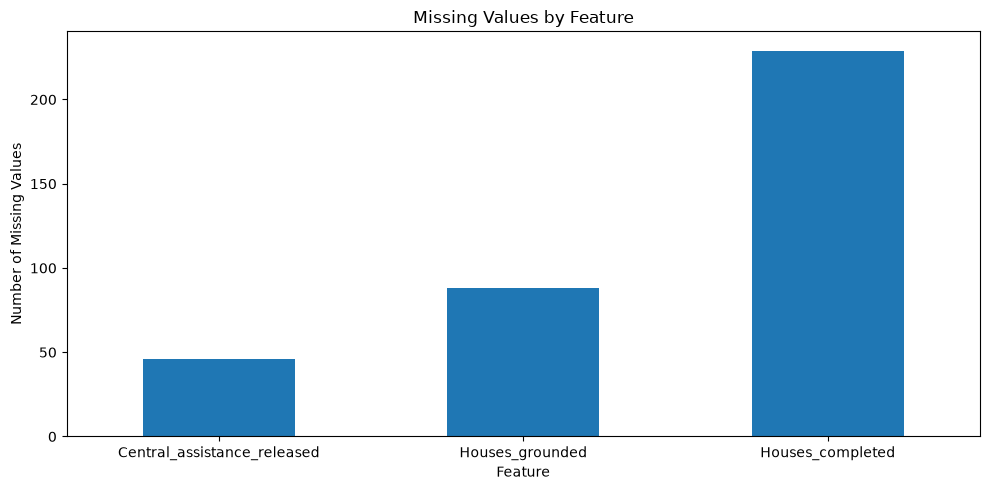

In [21]:
plt.figure(figsize=(10,5))

missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

missing_counts.plot(kind = "bar")

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
categorical_columns = ["Country", "State", "Year"]

for col in categorical_columns:
    print(df[col].value_counts(dropna=False).head(20))

Country
India    5113
Name: count, dtype: int64
State
Uttar Pradesh        802
Tamil Nadu           721
Madhya Pradesh       420
Maharashtra          416
Karnataka            303
Rajasthan            266
Bihar                264
Gujarat              203
Chhattisgarh         185
Punjab               172
Andhra Pradesh       147
Telangana            145
West Bengal          136
Odisha               120
Assam                115
Uttarakhand          108
Kerala                95
Haryana               86
Jammu And Kashmir     80
Himachal Pradesh      71
Name: count, dtype: int64
Year
Calendar Year (Jan - Dec), 2025    5113
Name: count, dtype: int64


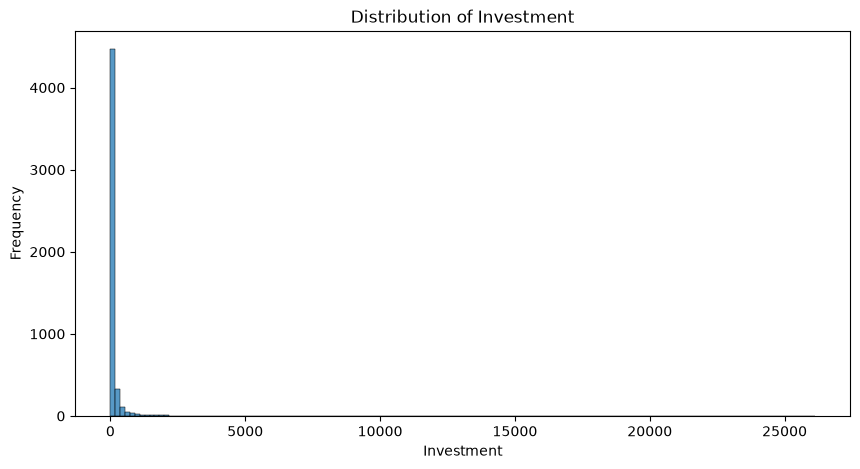

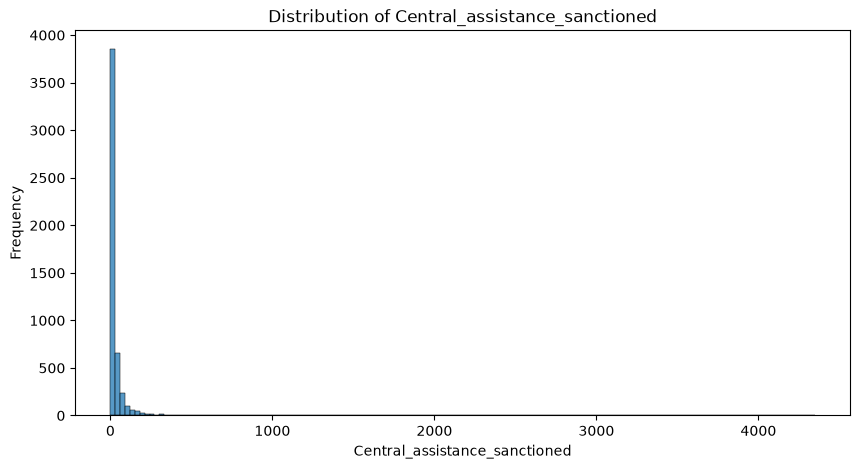

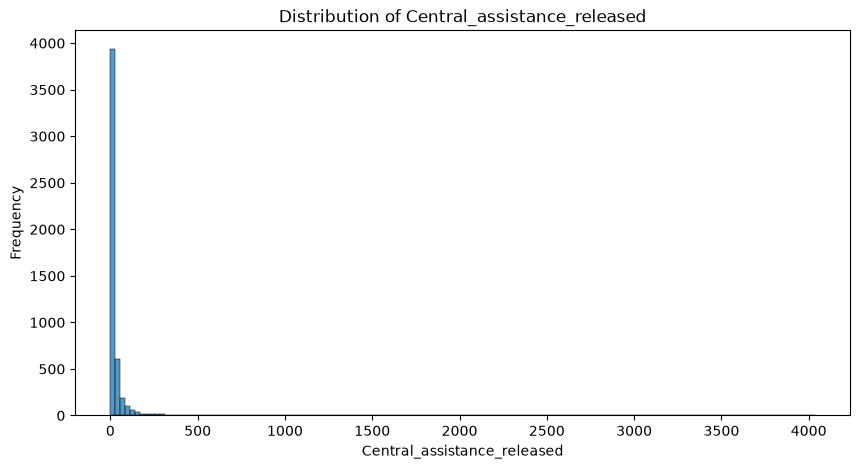

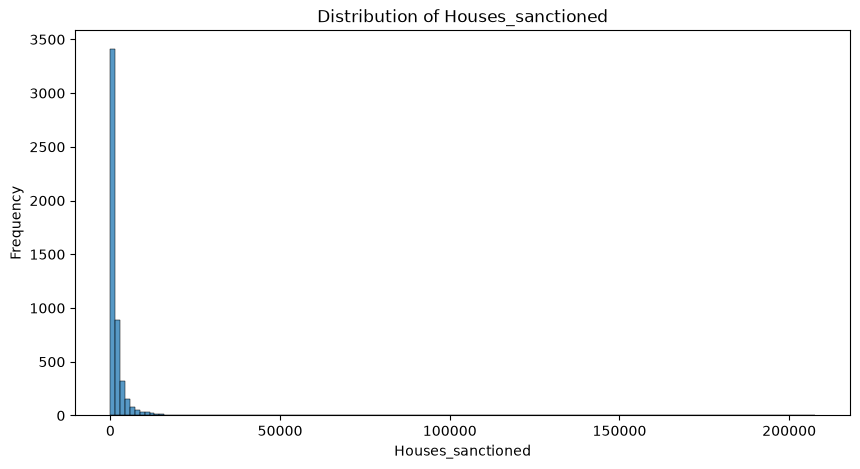

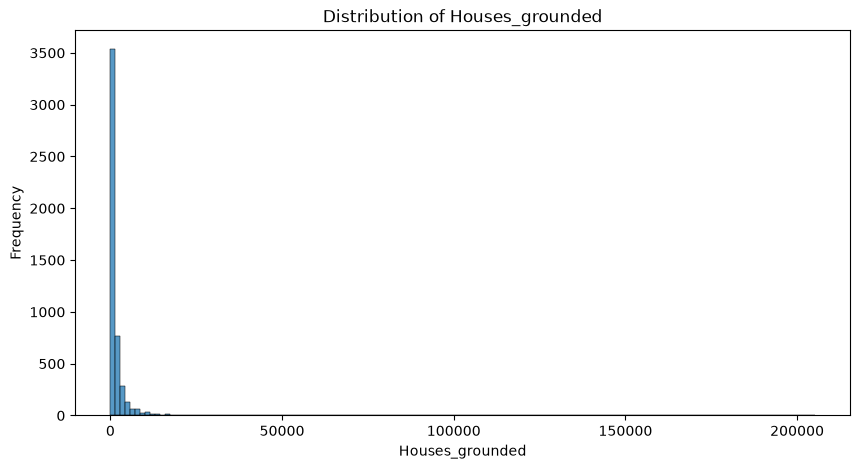

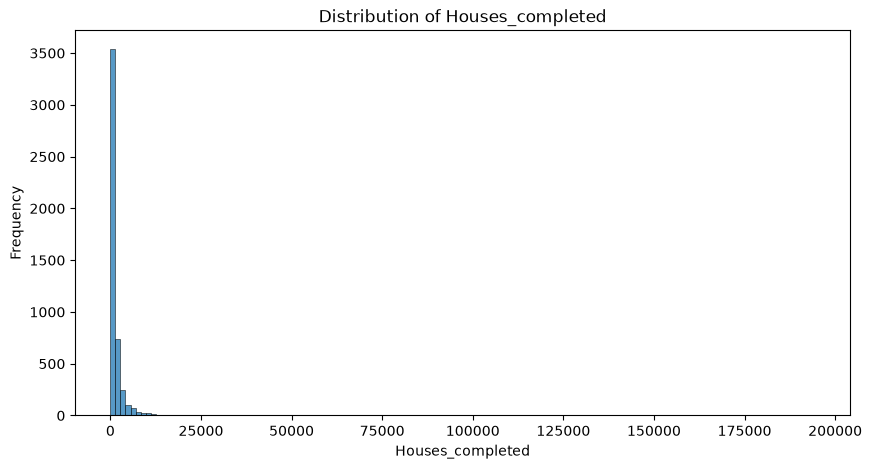

In [23]:
numerical_columns = ["Investment", "Central_assistance_sanctioned", "Central_assistance_released", "Houses_sanctioned", "Houses_grounded", "Houses_completed"]

for col in numerical_columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

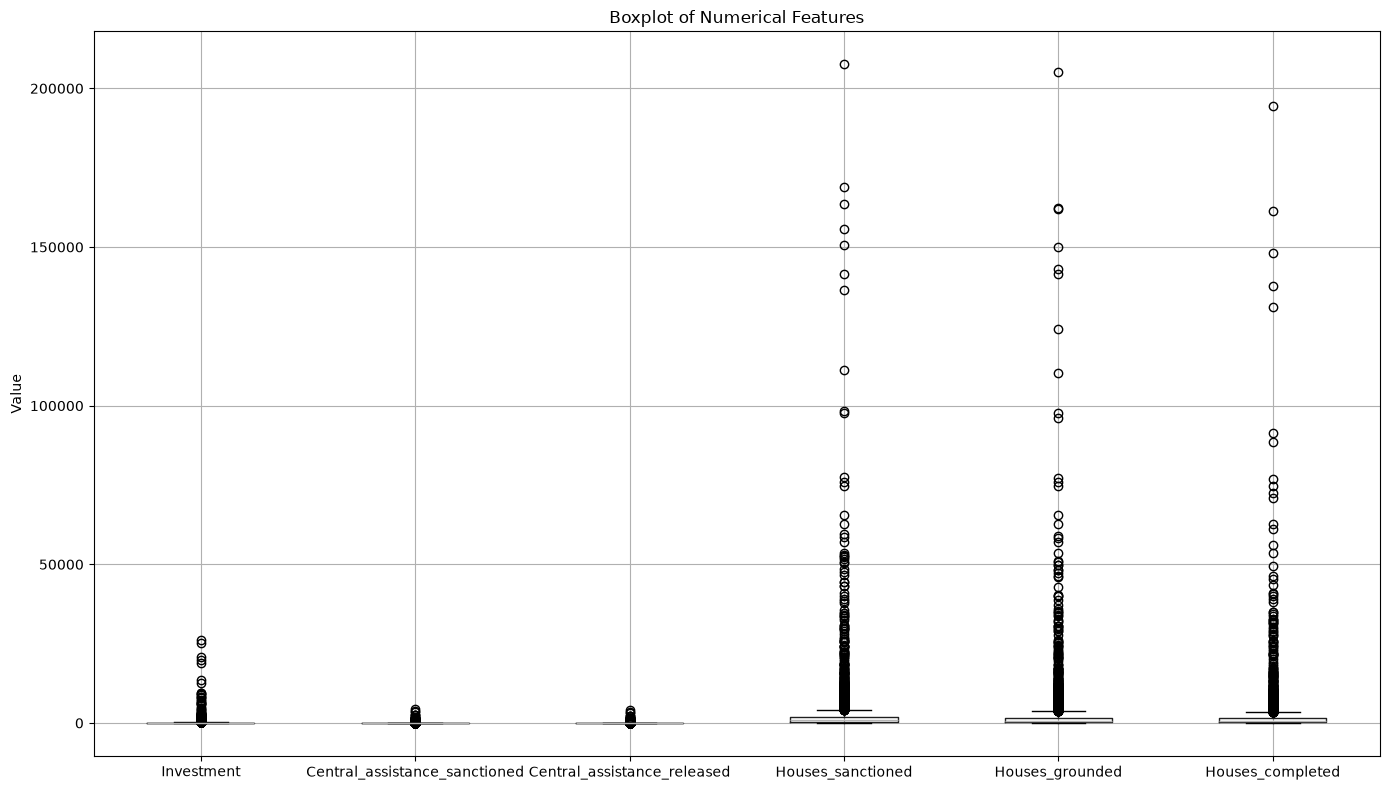

In [24]:
plt.figure(figsize=(14, 8))

df[numerical_columns].boxplot()

plt.title("Boxplot of Numerical Features")
plt.ylabel("Value")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

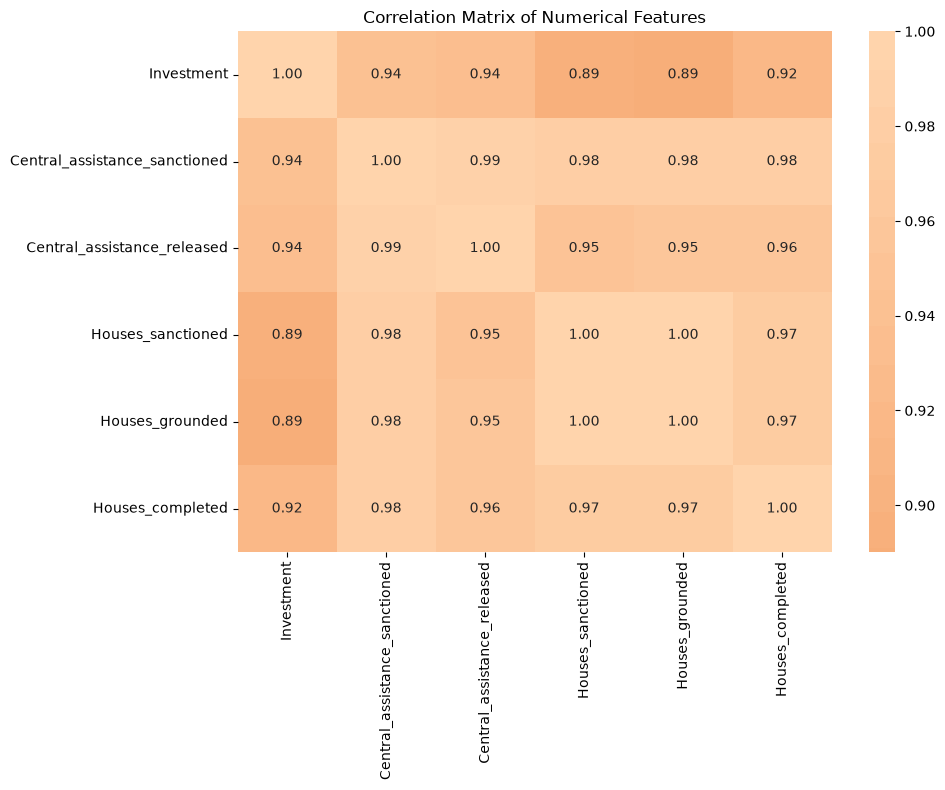

In [25]:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [26]:
logical_issues = df[
    (df["Houses_completed"] > df["Houses_grounded"]) |
    (df["Houses_grounded"] > df["Houses_sanctioned"])
]

print("Records violating expected housing progression:")
print(len(logical_issues))

Records violating expected housing progression:
0


In [27]:
df["Grounding_rate"] = (
    df["Houses_grounded"] /
    df["Houses_sanctioned"]
)

df["Completion_rate"] = (
    df["Houses_completed"] /
    df["Houses_sanctioned"]
)

df["Grounded_completion_rate"] = (
    df["Houses_completed"] /
    df["Houses_grounded"]
)

In [28]:
df[
    [
        "Grounding_rate",
        "Completion_rate",
        "Grounded_completion_rate"
    ]
] = df[
    [
        "Grounding_rate",
        "Completion_rate",
        "Grounded_completion_rate"
    ]
].replace(
    [np.inf, -np.inf],
    np.nan
)

In [29]:
df[
    [
        "Grounding_rate",
        "Completion_rate",
        "Grounded_completion_rate"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Grounding_rate,5025.0,0.860666,0.213757,0.001152,0.819005,0.956275,1.000000,1.0
Completion_rate,4884.0,0.763613,0.225198,0.001416,0.647004,0.843035,0.934802,1.0
Grounded_completion_rate,4884.0,0.863726,0.168031,0.003049,0.813995,0.930481,0.976772,1.0


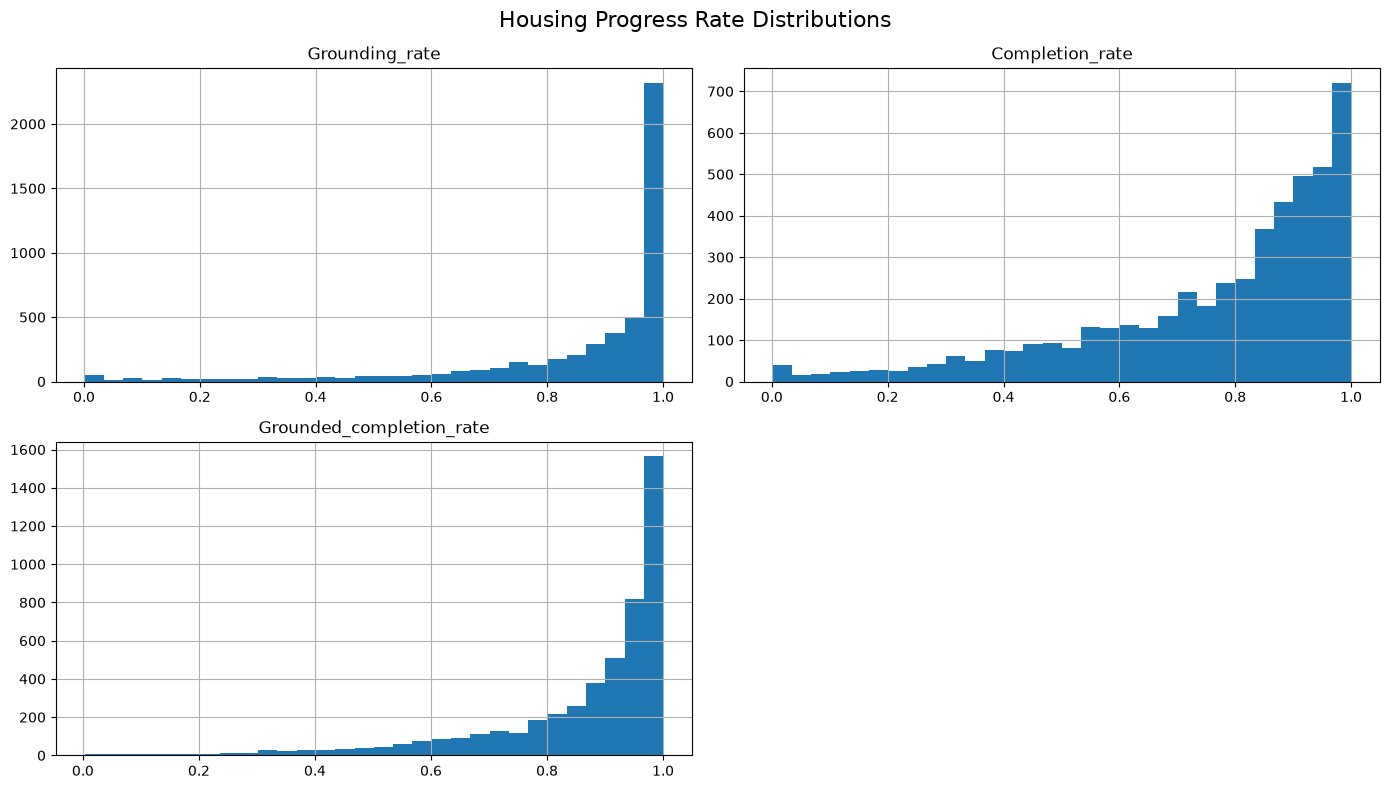

In [30]:
df[
    [
        "Grounding_rate",
        "Completion_rate",
        "Grounded_completion_rate"
    ]
].hist(
    figsize=(14, 8),
    bins=30
)

plt.suptitle(
    "Housing Progress Rate Distributions",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [31]:
df.to_csv(
    "../data/processed/eda_dataset.csv",
    index=False
)

In [32]:
numeric_columns = [
    "Investment",
    "Central_assistance_sanctioned",
    "Central_assistance_released",
    "Houses_sanctioned",
    "Houses_grounded",
    "Houses_completed"
]

outlier_summary = []

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers,
        "Outlier_Percentage": outliers / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Investment,16.59,92.79,76.20,-97.710,207.090,574,11.226286
1,Central_assistance_sanctioned,5.33,29.77,24.44,-31.330,66.430,518,10.131039
2,Central_assistance_released,3.94,25.23,21.29,-27.995,57.165,514,10.052807
3,Houses_sanctioned,332.00,1888.00,1556.00,-2002.000,4222.000,508,9.935459
4,Houses_grounded,264.00,1688.00,1424.00,-1872.000,3824.000,512,10.013691
5,Houses_completed,245.00,1507.25,1262.25,-1648.375,3400.625,469,9.172697


In [33]:
ratio_columns = [
    "Grounding_rate",
    "Completion_rate",
    "Grounded_completion_rate"
]

ratio_outlier_summary = []

for col in ratio_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    ratio_outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers,
        "Outlier_Percentage": outliers / len(df) * 100
    })

ratio_outlier_summary = pd.DataFrame(
    ratio_outlier_summary
)

ratio_outlier_summary

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Grounding_rate,0.819005,1.000000,0.180995,0.547511,1.271493,462,9.035791
1,Completion_rate,0.647004,0.934802,0.287797,0.215309,1.366498,154,3.011930
2,Grounded_completion_rate,0.813995,0.976772,0.162777,0.569829,1.220937,350,6.845296


In [34]:
df[
    [
        "State",
        "City",
        "Houses_sanctioned",
        "Houses_grounded",
        "Houses_completed",
        "Grounding_rate",
        "Completion_rate"
    ]
].sort_values(
    "Completion_rate"
).head(20)

,State,City,Houses_sanctioned,Houses_grounded,Houses_completed,Grounding_rate,Completion_rate
3972,Telangana,"Luxettipet, Municipality",706.0,1.0,1.0,0.001416,0.001416
2472,Maharashtra,"Tirthapuri, Town Panchayat",1129.0,331.0,2.0,0.293180,0.001771
2114,Maharashtra,"Angar, Town Panchayat",507.0,328.0,1.0,0.646943,0.001972
4031,Telangana,"Toopran, Municipality",538.0,2.0,2.0,0.003717,0.003717
4039,Telangana,"Wyra, Municipality",1423.0,6.0,6.0,0.004216,0.004216
3926,Telangana,"Chennur, Municipality",937.0,304.0,4.0,0.324440,0.004269
3999,Telangana,"Naspur, Municipality",2322.0,10.0,10.0,0.004307,0.004307
3950,Telangana,"Jalapally, Municipality",1639.0,8.0,8.0,0.004881,0.004881
3925,Telangana,"Chandur, Municipality",515.0,3.0,3.0,0.005825,0.005825
4023,Telangana,"Sulthanabad, Municipality",1073.0,7.0,7.0,0.006524,0.006524


In [35]:
df[
    [
        "State",
        "City",
        "Houses_sanctioned",
        "Houses_grounded",
        "Houses_completed",
        "Grounding_rate",
        "Completion_rate"
    ]
].sort_values(
    "Grounding_rate"
).head(20)


,State,City,Houses_sanctioned,Houses_grounded,Houses_completed,Grounding_rate,Completion_rate
322,Bihar,"Asthawan, Town Panchayat",868.0,1.0,NaN,0.001152,NaN
406,Bihar,"Goraul, Town Panchayat",815.0,1.0,NaN,0.001227,NaN
3972,Telangana,"Luxettipet, Municipality",706.0,1.0,1.0,0.001416,0.001416
4031,Telangana,"Toopran, Municipality",538.0,2.0,2.0,0.003717,0.003717
412,Bihar,"Hata, Town Panchayat",506.0,2.0,NaN,0.003953,NaN
4039,Telangana,"Wyra, Municipality",1423.0,6.0,6.0,0.004216,0.004216
3999,Telangana,"Naspur, Municipality",2322.0,10.0,10.0,0.004307,0.004307
3950,Telangana,"Jalapally, Municipality",1639.0,8.0,8.0,0.004881,0.004881
3925,Telangana,"Chandur, Municipality",515.0,3.0,3.0,0.005825,0.005825
4023,Telangana,"Sulthanabad, Municipality",1073.0,7.0,7.0,0.006524,0.006524


In [36]:
df[
    [
        "State",
        "City",
        "Investment",
        "Central_assistance_sanctioned",
        "Central_assistance_released",
        "Houses_sanctioned",
        "Houses_grounded",
        "Houses_completed"
    ]
].sort_values(
    "Investment",
    ascending=False
).head(20)

,State,City,Investment,Central_assistance_sanctioned,Central_assistance_released,Houses_sanctioned,Houses_grounded,Houses_completed
2402,Maharashtra,Pune Municipal Corporation,26124.59,3375.63,3072.19,155747.0,150077.0,148161.0
783,Gujarat,Ahmedabad Municipal Corporation,25327.17,4349.10,4035.68,207593.0,205196.0,194423.0
1313,Karnataka,Bengaluru Municipal Corporation,20837.81,2454.33,2127.72,136578.0,124019.0,88666.0
944,Gujarat,Surat Municipal Corporation,19765.68,3635.89,3599.23,163486.0,161968.0,161225.0
3946,Telangana,Hyderabad Municipal Corporation,18800.31,2593.68,2075.28,150782.0,143207.0,131236.0
3272,Tamil Nadu,Chennai Municipal Corporation,13411.39,1735.12,1466.82,97779.0,96138.0,76843.0
2470,Maharashtra,"Thane, Municipal Corporation",12481.96,1530.39,1514.37,62864.0,62864.0,62864.0
964,Gujarat,Vadodara Municipal Corporation,9417.02,1713.55,1624.70,77678.0,77166.0,71037.0
921,Gujarat,Rajkot Municipal Corporation,9409.46,1676.70,1597.06,75976.0,75800.0,74573.0
2379,Maharashtra,"Panvel, Municipal Corporation",8989.70,861.40,767.98,40047.0,39986.0,31802.0


In [37]:
df["Investment_per_house"] = (
    df["Investment"] /
    df["Houses_sanctioned"]
)

df["Investment_per_house"] = (
    df["Investment_per_house"]
    .replace([np.inf, -np.inf], np.nan)
)

df["Investment_per_house"].describe()

count    5113.000000
mean        0.057687
std         0.032194
min         0.020000
25%         0.039046
50%         0.048021
75%         0.064979
max         0.306111
Name: Investment_per_house, dtype: float64

In [38]:
df[
    [
        "State",
        "City",
        "Investment",
        "Houses_sanctioned",
        "Investment_per_house"
    ]
].sort_values(
    "Investment_per_house",
    ascending=False
).head(20)

,State,City,Investment,Houses_sanctioned,Investment_per_house
3633,Tamil Nadu,"Perungudi, Municipal Corporation",33.06,108.0,0.306111
3649,Tamil Nadu,"Porur, Municipality",124.49,427.0,0.291546
3848,Tamil Nadu,"Valasaravakkam, Municipality",15.63,56.0,0.279107
3475,Tamil Nadu,"Maduravoyal, Municipality",68.13,246.0,0.276951
3710,Tamil Nadu,"Sholinganallur, Municipal Corporation",624.76,2306.0,0.270928
3189,Tamil Nadu,"Alandur, Municipal Corporation",79.31,303.0,0.261749
3667,Tamil Nadu,"Puzhithivakkam, Municipal Corporation",17.26,66.0,0.261515
3589,Tamil Nadu,"Pallikaranai, Municipal Corporation",116.22,447.0,0.260000
0,Andaman And Nicobar Islands,"Port Blair, Municipality",95.83,376.0,0.254867
4941,Uttarakhand,Mussorie-Dehradun Development Authority,173.88,704.0,0.246989


In [39]:
df["Assistance_release_rate"] = (
    df["Central_assistance_released"] /
    df["Central_assistance_sanctioned"]
)

df["Assistance_release_rate"] = (
    df["Assistance_release_rate"]
    .replace([np.inf, -np.inf], np.nan)
)

df["Assistance_release_rate"].describe()

count    5067.000000
mean        0.854703
std         2.374504
min         0.001887
25%         0.707168
50%         0.872564
75%         0.958212
max       167.500000
Name: Assistance_release_rate, dtype: float64

In [40]:
print("=" * 70)
print("EDA CONCLUSION")
print("=" * 70)

print("""
Key observations from exploratory data analysis:

1. The dataset contains PMAY-U 2025 housing and financial records.
2. Numerical variables exhibit strong right-skewness and substantial extreme values.
3. Investment and housing-related variables contain a significant number of
   statistical outliers according to the IQR criterion.
4. Housing progress ratios are strongly concentrated toward higher values,
   while a smaller group of records exhibits substantially lower progress.
5. Financial and housing variables show very strong correlations, indicating
   considerable feature redundancy.
6. Statistical outliers cannot automatically be interpreted as corruption,
   since large projects can legitimately produce extreme values.
7. Derived relationship-based features such as completion rate, grounding rate,
   investment per house, and assistance release rate may provide more meaningful
   signals for anomaly detection.
8. An explicit corruption/anomaly ground-truth label is not available in the
   dataset, motivating an unsupervised or semi-supervised anomaly detection
   methodology combined with domain-based consistency checks.
""")

EDA CONCLUSION

Key observations from exploratory data analysis:

1. The dataset contains PMAY-U 2025 housing and financial records.
2. Numerical variables exhibit strong right-skewness and substantial extreme values.
3. Investment and housing-related variables contain a significant number of
   statistical outliers according to the IQR criterion.
4. Housing progress ratios are strongly concentrated toward higher values,
   while a smaller group of records exhibits substantially lower progress.
5. Financial and housing variables show very strong correlations, indicating
   considerable feature redundancy.
6. Statistical outliers cannot automatically be interpreted as corruption,
   since large projects can legitimately produce extreme values.
7. Derived relationship-based features such as completion rate, grounding rate,
   investment per house, and assistance release rate may provide more meaningful
   signals for anomaly detection.
8. An explicit corruption/anomaly ground-truth label

In [41]:
import os

os.makedirs("../data/processed", exist_ok=True)

EDA_OUTPUT = "../data/processed/eda_dataset.csv"

df.to_csv(
    EDA_OUTPUT,
    index=False
)

print(f"Saved: {EDA_OUTPUT}")
print(f"Shape: {df.shape}")

Saved: ../data/processed/eda_dataset.csv
Shape: (5113, 15)


In [43]:
eda_summary = {
    "rows": len(df),
    "columns_original": 10,
    "columns_after_feature_engineering": len(df.columns),
    "duplicate_records": int(df.duplicated().sum()),
    "total_missing_values": int(df.isnull().sum().sum()),
    "housing_logical_inconsistencies": int(len(logical_issues))
}

eda_summary

{'rows': 5113,
 'columns_original': 10,
 'columns_after_feature_engineering': 15,
 'duplicate_records': 0,
 'total_missing_values': 955,
 'housing_logical_inconsistencies': 0}

In [44]:
import json

with open(
    "../data/processed/eda_summary.json",
    "w"
) as f:
    json.dump(
        eda_summary,
        f,
        indent=4
    )

print("EDA summary saved.")

EDA summary saved.
